In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cpu


In [2]:
class Generator(nn.Module):

    def __init__(self, z_dim=64):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(z_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z)


class Critic(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(784, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.net(x)

In [3]:
def gradient_penalty(critic, real, fake):

    alpha = torch.rand(
        real.size(0), 1,
        device=device
    )

    interpolated = (
        alpha * real +
        (1 - alpha) * fake
    )

    interpolated.requires_grad_(True)

    score = critic(interpolated)

    gradients = torch.autograd.grad(
        outputs=score,
        inputs=interpolated,
        grad_outputs=torch.ones_like(score),
        create_graph=True
    )[0]

    gradients = gradients.view(
        gradients.size(0), -1
    )

    norm = gradients.norm(2, dim=1)

    return ((norm - 1) ** 2).mean()

In [4]:
G = Generator().to(device)
C = Critic().to(device)

g_opt = torch.optim.Adam(
    G.parameters(), lr=0.0002,
    betas=(0.5, 0.9)
)

c_opt = torch.optim.Adam(
    C.parameters(), lr=0.0002,
    betas=(0.5, 0.9)
)

In [5]:
real = torch.randn(
    64, 784,
    device=device
).clamp(-1, 1)

z = torch.randn(
    64, 64,
    device=device
)

fake = G(z)

print("Real:", real.shape)
print("Fake:", fake.shape)

Real: torch.Size([64, 784])
Fake: torch.Size([64, 784])


In [6]:
gp_weight = 10

c_loss = (
    C(fake.detach()).mean()
    - C(real).mean()
    + gp_weight *
      gradient_penalty(C, real, fake.detach())
)

g_loss = -C(fake).mean()

print("Critic Loss:", c_loss.item())
print("Generator Loss:", g_loss.item())

Critic Loss: 8.049856185913086
Generator Loss: -0.05581624060869217


In [7]:
# Train critic
c_opt.zero_grad()

c_loss.backward()

c_opt.step()


# Train generator
z = torch.randn(
    64, 64,
    device=device
)

fake = G(z)

g_loss = -C(fake).mean()

g_opt.zero_grad()
g_loss.backward()
g_opt.step()

print("Training step completed.")

Training step completed.


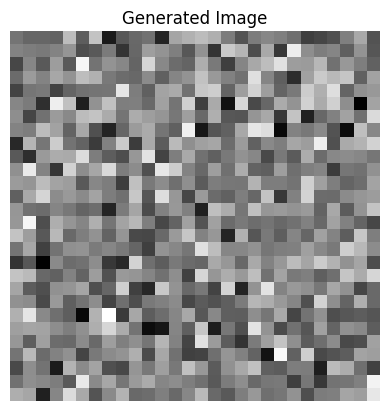

In [8]:
with torch.no_grad():

    z = torch.randn(
        1, 64,
        device=device
    )

    sample = G(z).reshape(28, 28).cpu()

plt.imshow(sample, cmap="gray")
plt.title("Generated Image")
plt.axis("off")
plt.show()

In [9]:
print("WGAN-GP implementation completed.")
print("Generator, critic and gradient penalty were implemented.")

WGAN-GP implementation completed.
Generator, critic and gradient penalty were implemented.
